### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     1615136

**Student Name:**      Skanda Ramanan


## How to run this notebook

**Environment:** Python 3 with Jupyter. Install dependencies if needed:

`pip install pandas numpy scikit-learn matplotlib seaborn`

**Data files:** Place these CSV files in the **same directory** as this notebook:

- `adult_supervised_train.csv`
- `adult_test.csv`
- `adult_unlabelled.csv`
- `adult_unlabelled_with_labels.csv` 

**Execution:** Run cells **in order from top to bottom**, or use **Run → Restart Kernel and Run All Cells**. Cells must run in order, and build upon each other.

**Reproducibility:** Semi-supervised/active-learning steps use a fixed seed (`RANDOM_SEED = 42`). The notebook uses `random_state=RANDOM_SEED` and `np.random.default_rng(...)` for deterministic splits and acquisition. Re-running the full notebook should reproduce the same metrics and figures.



### AI Declaration
I acknowledge the use of Claude AI (https://claude.ai/) to generate pieces of code as permitted by the rules of the assignment. I entered the following prompts:


Prompt: “Help me format these outputs using print statements, clear headers and formatting ready for my report”.    
Use: Improve the formatting of the output, which originally required a lot of manual work, in order to produce text outputs cleanly and ready for use in my report.


Prompt: "Help me produce unique features for the High Confidence >50k and <=50k predictions. Currently we produce very similar features, which makes analysis harder. I want some kind of diversity rules in this cell, to prevent identical features from being produced, especially as it relates to capital-gains".    
Use: I used this in Question 2.3, in order to find examples of High confidence. I used the results in my report, as the new results were more varied, while still high confidence, producing higher quality analysis.


Prompt: "How should i produce a graph to compare R values for each of these models? The graph is weird with bad axes, how can this be improved upon?".    
Use: Improve the prediction confidence graph used for q4, including creating the zoomed in graph, in order to produce cleaner figures for use in the report.


Prompt: “Design a Hybrid Label Acquisition model, to balance using uncertainity and novelty of features for a 3rd label acquisition method”.   
Use: Helped refine and produce the Hybrid-200 label acquisition model, including determining how to weight each of the diversity metrics.

## 1. Supervised model training


In [12]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TRAIN_PATH = 'adult_supervised_train.csv'
TARGET_COLUMN = 'income'
CLASS_LABELS = {0: '<=50K', 1: '>50K'}
CONTINUOUS_FEATURES = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL_FEATURES = ['workclass', 'education', 'marital-status', 'occupation',
                        'relationship', 'race', 'sex', 'native-country']

# Data Loading for Training
train_df = pd.read_csv(TRAIN_PATH)
# Basic info about training data
print(f"Raw training set shape: {train_df.shape}")
print(f"\nColumn dtypes:\n{train_df.dtypes}")
print("\nFirst 3 rows:")
train_df.head(3)

Raw training set shape: (16280, 15)

Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

First 3 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,63,Private,219337,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,45,United-States,<=50K
1,44,State-gov,33658,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,7688,0,50,United-States,>50K
2,18,Private,157193,12th,8,Never-married,Other-service,Own-child,White,Male,0,0,30,Italy,<=50K


In [13]:
# --- Preprocessing ---


def preprocess_adult_frame(df):
    """Clean a labelled Adult split: missing values dropped, fnlwgt removed, income encoded."""
    cleaned_df = df.copy()

    # The  CSVs store missing values as blank fields, which pandas usually reads as NaN, not as '?' as stated in assignment spec
    # Also catch any whitespace only strings to remove them
    cleaned_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

    rows_before = len(cleaned_df)
    cleaned_df.dropna(inplace=True)
    rows_after = len(cleaned_df)
    
    cleaned_df = cleaned_df.drop(columns=['fnlwgt']).copy()
    cleaned_df[TARGET_COLUMN] = cleaned_df[TARGET_COLUMN].map({'<=50K': 0, '>50K': 1})

    return cleaned_df, rows_before - rows_after


train_df, dropped_rows = preprocess_adult_frame(train_df)
X_train_cont = train_df[CONTINUOUS_FEATURES].astype(float)
X_train_cat = train_df[CATEGORICAL_FEATURES].copy()
y_train = train_df[TARGET_COLUMN]

class_distribution = y_train.value_counts().sort_index().rename(index=CLASS_LABELS)

rows_total = len(train_df) + dropped_rows
print(f"Dropped {dropped_rows} rows with missing values ({rows_total} -> {len(train_df)})")
print(f"\nContinuous features: {CONTINUOUS_FEATURES}")
print(f"Categorical features: {CATEGORICAL_FEATURES}")
print(f"\nClass distribution:\n{class_distribution}")

Dropped 1204 rows with missing values (16280 -> 15076)

Continuous features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Class distribution:
income
<=50K    11369
>50K      3707
Name: count, dtype: int64


In [14]:
# --- Train Mixed Naive Bayes ---


def fit_mixed_nb(X_cont, X_cat, y, alpha=1.0):
    """Fit Gaussian Naive Bayes on continuous features and Categorical NB on categorical ones."""
    gnb = GaussianNB()
    gnb.fit(X_cont, y)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_enc = encoder.fit_transform(X_cat).astype(int)

    cnb = CategoricalNB(alpha=alpha)
    cnb.fit(X_cat_enc, y)

    return {
        'gnb': gnb,
        'cnb': cnb,
        'encoder': encoder,
        'classes': gnb.classes_,
        'alpha': alpha,
    }


def transform_categorical_features(X_cat, encoder):
    """Apply the training encoder so category handling stays consistent everywhere."""
    return encoder.transform(X_cat).astype(int)


def gaussian_log_likelihood(X_cont, gnb):
    """Compute Gaussian feature log-likelihoods using the learned public parameters."""
    X_cont = np.asarray(X_cont, dtype=float)
    variances = np.maximum(gnb.var_, 1e-9)
    means = gnb.theta_

    squared_error = (X_cont[:, None, :] - means[None, :, :]) ** 2
    log_density = -0.5 * (
        np.log(2 * np.pi * variances)[None, :, :] + squared_error / variances[None, :, :]
    )
    return log_density.sum(axis=2)


def categorical_log_likelihood(X_cat_enc, cnb):
    """Sum the learned categorical log-probabilities feature by feature."""
    X_cat_enc = np.asarray(X_cat_enc, dtype=int)
    n_samples = X_cat_enc.shape[0]
    n_classes = len(cnb.class_count_)
    log_likelihood = np.zeros((n_samples, n_classes))

    for feature_idx, feature_log_prob in enumerate(cnb.feature_log_prob_):
        encoded_values = X_cat_enc[:, feature_idx]
        known_mask = encoded_values >= 0

        # Unknown categories are ignored here; they contribute equally to both classes.
        if np.any(known_mask):
            log_likelihood[known_mask] += feature_log_prob[:, encoded_values[known_mask]].T

    return log_likelihood


def predict_mixed_nb(X_cont, X_cat, model):
    """Combine the continuous and categorical pieces into one posterior score."""
    X_cat_enc = transform_categorical_features(X_cat, model['encoder'])
    log_prior = np.log(model['gnb'].class_prior_)
    log_posterior = (
        log_prior
        + gaussian_log_likelihood(X_cont, model['gnb'])
        + categorical_log_likelihood(X_cat_enc, model['cnb'])
    )
    predictions = model['classes'][np.argmax(log_posterior, axis=1)]
    return predictions, log_posterior


mixed_nb_model = fit_mixed_nb(X_train_cont, X_train_cat, y_train, alpha=1.0)
gnb = mixed_nb_model['gnb']
cnb = mixed_nb_model['cnb']
encoder = mixed_nb_model['encoder']

print('Mixed Naive Bayes model trained successfully.')
print(f"  Classes: {gnb.classes_}")
print(f"  Laplace smoothing alpha: {mixed_nb_model['alpha']}")

y_pred_train, train_log_posterior = predict_mixed_nb(X_train_cont, X_train_cat, mixed_nb_model)
train_acc = accuracy_score(y_train, y_pred_train)
print(f"\nTraining accuracy (sanity check): {train_acc:.4f}")

Mixed Naive Bayes model trained successfully.
  Classes: [0 1]
  Laplace smoothing alpha: 1.0

Training accuracy (sanity check): 0.8289


In [15]:
# --- Q1.1: Prior Probabilities ---

# P(<=50k)
prior_low = gnb.class_prior_[0]  
# P(>50K) 
prior_high = gnb.class_prior_[1]  

print("Prior Probabilities P(c):")
print(f"  P(<=50K) = {prior_low:.4f}")
print(f"  P(>50K)  = {prior_high:.4f}")
print(f"\nClass ratio (<=50K : >50K) = {prior_low/prior_high:.2f} : 1")
print(f"\nThe training set exhibits class imbalance — the <=50K class is "
      f"~{prior_low/prior_high:.1f}x more frequent than >50K.")

Prior Probabilities P(c):
  P(<=50K) = 0.7541
  P(>50K)  = 0.2459

Class ratio (<=50K : >50K) = 3.07 : 1

The training set exhibits class imbalance — the <=50K class is ~3.1x more frequent than >50K.


In [16]:
# --- Q1.2: Continuous Feature Statistics per Class ---

# Extract learned parameters from GaussianNB
means = gnb.theta_       
variances = gnb.var_     
stds = np.sqrt(variances)

# Make a summary table
cont_stats = pd.DataFrame({
    'Feature': CONTINUOUS_FEATURES,
    'Mean (<=50K)': means[0],
    'Std (<=50K)': stds[0],
    'Mean (>50K)': means[1],
    'Std (>50K)': stds[1],
})

# Measure separation using difference in mean over sqrt of sum of variances
cont_stats["Separation score"] = np.abs(means[1] - means[0]) / np.sqrt(variances[0] + variances[1])
cont_stats = cont_stats.sort_values("Separation score", ascending=False)

print("Continuous Feature Statistics by Class:")
print("=" * 90)
print(cont_stats.to_string(index=False, float_format='{:.4f}'.format))
print("\n(Sorted by separation score — larger values indicate greater separation between classes after accounting for class standard deviations)")

Continuous Feature Statistics by Class:
       Feature  Mean (<=50K)  Std (<=50K)  Mean (>50K)  Std (>50K)  Separation score
 education-num        9.6293       2.4478      11.5946      2.3650            0.5774
           age       37.0508      13.7119      43.9385     10.3027            0.4016
hours-per-week       39.4286      11.9108      45.6423     10.3961            0.3930
  capital-gain      157.6660    1017.8632    3607.1467  13616.6230            0.2526
  capital-loss       55.9746     316.0201     202.3620    603.9910            0.2147

(Sorted by separation score — larger values indicate greater separation between classes after accounting for class standard deviations)


In [17]:
# --- Q1.3: Categorical Feature Probability Ratios ---

from IPython.display import display

ratio_records = []

for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
    # Log-probabilities for this feature: shape (n_classes, n_categories)
    log_probs = cnb.feature_log_prob_[feat_idx]
    probs = np.exp(log_probs)  # convert to probabilities

    # Category labels from the encoder
    categories = encoder.categories_[feat_idx]

    for cat_idx, cat_value in enumerate(categories):
        p_given_low = probs[0, cat_idx]   # P(v | <=50K)
        p_given_high = probs[1, cat_idx]  # P(v | >50K)

        # R for >50K
        r_high = p_given_high / p_given_low
        # R for <=50K
        r_low = p_given_low / p_given_high

        ratio_records.append({
            'Feature': feat_name,
            'Value': cat_value,
            'P(v|<=50K)': p_given_low,
            'P(v|>50K)': p_given_high,
            'R (>50K)': r_high,
            'R (<=50K)': r_low,
        })

ratio_df = pd.DataFrame(ratio_records)

# Best category value per feature for each class
best_per_feature_high = ratio_df.loc[
    ratio_df.groupby('Feature')['R (>50K)'].idxmax(),
    ['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (>50K)']
].sort_values('Feature')

best_per_feature_low = ratio_df.loc[
    ratio_df.groupby('Feature')['R (<=50K)'].idxmax(),
    ['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (<=50K)']
].sort_values('Feature')

print('Table 1 — Strongest category per feature for >50K (argmax R(>50K) within each feature)')
print('=' * 75)
display(best_per_feature_high.round(4))

print()
print('Table 2 — Strongest category per feature for <=50K (argmax R(<=50K) within each feature)')
print('=' * 75)
display(best_per_feature_low.round(4))

print()

# Top 5 most predictive of >50K (highest R for >50K)
top5_high = ratio_df.nlargest(5, 'R (>50K)')[['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (>50K)']]
print('Table 3 — Top 5 (feature, value) pairs by R(>50K) across all categorical features')
print('=' * 75)
display(top5_high.round(4))

print()

# Top 5 most predictive of <=50K (highest R for <=50K)
top5_low = ratio_df.nlargest(5, 'R (<=50K)')[['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (<=50K)']]
print('Table 4 — Top 5 (feature, value) pairs by R(<=50K) across all categorical features')
print('=' * 75)
display(top5_low.round(4))

Table 1 — Strongest category per feature for >50K (argmax R(>50K) within each feature)


,Feature,Value,P(v|<=50K),P(v|>50K),R (>50K)
21,education,Prof-school,0.0069,0.0545,7.9587
24,marital-status,Married-AF-spouse,0.0004,0.0019,4.2882
91,native-country,Taiwan,0.0008,0.0027,3.3832
33,occupation,Exec-managerial,0.0915,0.2534,2.7685
51,race,Asian-Pac-Islander,0.0259,0.0294,1.1322
49,relationship,Wife,0.0330,0.0905,2.7450
56,sex,Male,0.6145,0.8469,1.3782
3,workclass,Self-emp-inc,0.0243,0.0792,3.2510



Table 2 — Strongest category per feature for <=50K (argmax R(<=50K) within each feature)


,Feature,Value,P(v|<=50K),P(v|>50K),R (<=50K)
13,education,9th,0.0196,0.0030,6.6294
27,marital-status,Never-married,0.4076,0.0668,6.1043
81,native-country,Mexico,0.0248,0.0045,5.4673
38,occupation,Priv-house-serv,0.0064,0.0005,11.9315
50,race,Amer-Indian-Eskimo,0.0116,0.0051,2.2673
47,relationship,Own-child,0.1858,0.0097,19.1680
55,sex,Female,0.3855,0.1531,2.5176
2,workclass,Private,0.7580,0.6497,1.1667



Table 3 — Top 5 (feature, value) pairs by R(>50K) across all categorical features


,Feature,Value,P(v|<=50K),P(v|>50K),R (>50K)
21,education,Prof-school,0.0069,0.0545,7.9587
17,education,Doctorate,0.0045,0.0320,7.1354
24,marital-status,Married-AF-spouse,0.0004,0.0019,4.2882
19,education,Masters,0.0357,0.1268,3.5551
91,native-country,Taiwan,0.0008,0.0027,3.3832



Table 4 — Top 5 (feature, value) pairs by R(<=50K) across all categorical features


,Feature,Value,P(v|<=50K),P(v|>50K),R (<=50K)
47,relationship,Own-child,0.1858,0.0097,19.1680
38,occupation,Priv-house-serv,0.0064,0.0005,11.9315
37,occupation,Other-service,0.1389,0.0188,7.3831
46,relationship,Other-relative,0.0373,0.0054,6.9201
13,education,9th,0.0196,0.0030,6.6294


## 2. Supervised model evaluation

Raw test set shape: (16281, 15)
Dropped 1194 test rows with missing values (16281 -> 15087)

Overall test accuracy: 0.8307

Per-class breakdown:
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087



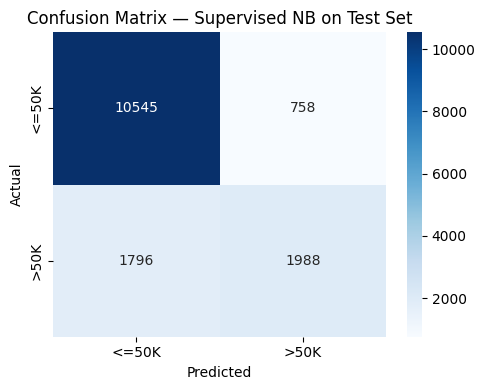

In [18]:
# --- Q2.1: Test Set Evaluation ---

TEST_PATH = 'adult_test.csv'

test_df_raw = pd.read_csv(TEST_PATH)
print(f"Raw test set shape: {test_df_raw.shape}")

test_df, dropped_test = preprocess_adult_frame(test_df_raw)
X_test_cont = test_df[CONTINUOUS_FEATURES].astype(float)
X_test_cat = test_df[CATEGORICAL_FEATURES].copy()
y_test = test_df[TARGET_COLUMN]

rows_total_test = len(test_df) + dropped_test
print(f"Dropped {dropped_test} test rows with missing values ({rows_total_test} -> {len(test_df)})")

# Predict on the held-out test set using the supervised model from Q1
y_pred_test, test_log_posterior = predict_mixed_nb(X_test_cont, X_test_cat, mixed_nb_model)

test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nOverall test accuracy: {test_acc:.4f}")
print(f"\nPer-class breakdown:")
print(classification_report(y_test, y_pred_test, target_names=['<=50K', '>50K']))

# Confusion matrix visualisation
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Supervised NB on Test Set')
plt.tight_layout()
plt.show()

In [ ]:
# --- Q2.2: Unseen Categories in Test Set ---

X_test_cat_enc = transform_categorical_features(X_test_cat, encoder)

# OrdinalEncoder sets unseen categories to -1
unseen_per_instance = (X_test_cat_enc == -1).any(axis=1)
n_unseen = unseen_per_instance.sum()

print(f"Test instances with at least one unseen category value: "
      f"{n_unseen} / {len(test_df)} ({n_unseen / len(test_df) * 100:.1f}%)\n")

# Per-feature breakdown 
for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
    col_unseen_count = (X_test_cat_enc[:, feat_idx] == -1).sum()
    if col_unseen_count > 0:
        train_vals = set(encoder.categories_[feat_idx])
        test_vals = set(X_test_cat[feat_name].unique())
        novel = sorted(test_vals - train_vals)
        print(f"  {feat_name}: {col_unseen_count} instance(s), unseen values = {novel}")

# Compare accuracy on the affected vs unaffected subsets
if n_unseen > 0:
    mask = unseen_per_instance
    n_seen = (~mask).sum()
    acc_unseen = accuracy_score(y_test.values[mask], y_pred_test[mask])
    acc_seen = accuracy_score(y_test.values[~mask], y_pred_test[~mask])
    print(f"\nAccuracy on instances WITH unseen values:    {acc_unseen:.4f} (n={n_unseen})")
    print(f"Accuracy on instances WITHOUT unseen values:  {acc_seen:.4f} (n={n_seen})")

print(f"\nHandling: unseen category values are encoded as -1 and skipped in the categorical "
      f"log-likelihood.\nThey contribute 0 to both class posteriors, so the prediction relies on "
      f"the remaining known features.\nNo test instances are discarded — every row still receives "
      f"a prediction.")

Test instances with at least one unseen category value: 1 / 15087 (0.0%)

  native-country: 1 instance(s), unseen values = ['Holand-Netherlands']

Accuracy on instances WITH unseen values:    0.0000 (n=1)
Accuracy on instances WITHOUT unseen values:  0.8308 (n=15086)

Handling: unseen category values are encoded as -1 and skipped in the categorical log-likelihood.
They contribute 0 to both class posteriors, so the prediction relies on the remaining known features.
No test instances are discarded — every row still receives a prediction.


(a) High-Confidence >50K Predictions (R >> 1)
 age   education     marital-status      occupation  hours-per-week  capital-gain actual predicted  correct         R
  47   Bachelors Married-civ-spouse Exec-managerial              55         99999   >50K      >50K     True 1.40e+217
  63     Masters Married-civ-spouse Farming-fishing              50         41310  <=50K      >50K    False 1.40e+217
  51 Prof-school           Divorced  Prof-specialty              60         27828   >50K      >50K     True 1.21e+160

(b) High-Confidence <=50K Predictions (R << 1)
 age education     marital-status        occupation  hours-per-week  capital-gain actual predicted  correct        R
  18      10th      Never-married     Other-service               3             0  <=50K     <=50K     True 9.24e-10
  35      11th          Separated   Priv-house-serv               8             0  <=50K     <=50K     True 8.88e-09
  23   7th-8th Married-civ-spouse Handlers-cleaners              30             0  

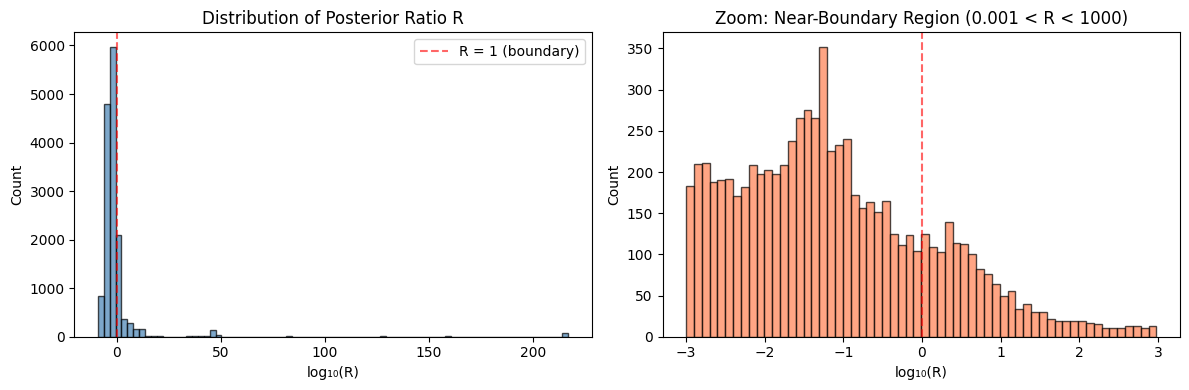

In [20]:
# --- Q2.3: Prediction Confidence (Posterior Ratio R) ---

log_ratio = test_log_posterior[:, 1] - test_log_posterior[:, 0]
R_values = np.exp(np.clip(log_ratio, -500, 500))

test_results = test_df.reset_index(drop=True).copy()
test_results['predicted'] = y_pred_test
test_results['R'] = R_values
test_results['correct'] = (test_results['predicted'] == test_results[TARGET_COLUMN])

DISPLAY_COLS = ['age', 'education', 'marital-status', 'occupation',
                'hours-per-week', 'capital-gain']

def format_examples(df, n=3):
    """Compact table of n examples with key features, actual/predicted labels, and R."""
    subset = df[DISPLAY_COLS].head(n).copy()
    subset['actual'] = df[TARGET_COLUMN].head(n).map(CLASS_LABELS).values
    subset['predicted'] = df['predicted'].head(n).map(CLASS_LABELS).values
    subset['correct'] = df['correct'].head(n).values
    subset['R'] = df['R'].head(n).apply(
        lambda r: f'{r:.2e}' if (r > 1e3 or r < 1e-3) else f'{r:.4f}'
    ).values
    return subset

def pick_diverse(pool, diversity_cols, n=3):
    """Pick n examples from a sorted pool, excluding rows sharing ANY diversity column value."""
    picks = []
    remaining = pool.copy()
    for _ in range(n):
        if remaining.empty:
            break
        top = remaining.iloc[0]
        picks.append(top.name)
        match_mask = pd.Series(False, index=remaining.index)
        for col in diversity_cols:
            match_mask = match_mask | (remaining[col] == top[col])
        remaining = remaining[~match_mask]
    return pool.loc[picks]

# (a) High-confidence >50K predictions (R > 1 significantly) — diverse profiles
high_50k_sorted = test_results[test_results['predicted'] == 1].sort_values('R', ascending=False)
high_50k_diverse = pick_diverse(high_50k_sorted, ['capital-gain', 'education', 'occupation'])
print("(a) High-Confidence >50K Predictions (R >> 1)")
print("=" * 110)
print(format_examples(high_50k_diverse).to_string(index=False))

print()

# (b) High-confidence <=50K predictions (R < 1 significantly) — diverse profiles
high_le50k_sorted = test_results[test_results['predicted'] == 0].sort_values('R', ascending=True)
high_le50k_diverse = pick_diverse(high_le50k_sorted, ['education', 'occupation', 'marital-status'])
print("(b) High-Confidence <=50K Predictions (R << 1)")
print("=" * 110)
print(format_examples(high_le50k_diverse).to_string(index=False))

print()

# (c) Near decision boundary (R closest to 1) — diverse profiles
boundary_sorted = test_results.loc[(test_results['R'] - 1.0).abs().argsort()]
boundary_diverse = pick_diverse(boundary_sorted, ['education', 'occupation', 'marital-status'])
print("(c) Near Decision Boundary (R ≈ 1)")
print("=" * 110)
print(format_examples(boundary_diverse).to_string(index=False))

# Overall confidence distribution
print(f"\nConfidence summary:")
print(f"  Median R (>50K predictions):  {test_results.loc[test_results['predicted']==1, 'R'].median():.2e}")
print(f"  Median R (<=50K predictions): {test_results.loc[test_results['predicted']==0, 'R'].median():.2e}")
print(f"  Instances with R > 1000 (very confident >50K):  {(R_values > 1000).sum()}")
print(f"  Instances with R < 0.001 (very confident <=50K): {(R_values < 0.001).sum()}")
print(f"  Instances with 0.5 < R < 2 (near boundary):     {((R_values > 0.5) & (R_values < 2)).sum()}")

# Distribution of log10(R) — full signed range shows both classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log10_R = np.log10(np.clip(R_values, 1e-300, None))
axes[0].hist(log10_R, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('log₁₀(R)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Posterior Ratio R')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.6, label='R = 1 (boundary)')
axes[0].legend()

# Zoom in on region near boundary
near = log10_R[(log10_R > -3) & (log10_R < 3)]
axes[1].hist(near, bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('log₁₀(R)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoom: Near-Boundary Region (0.001 < R < 1000)')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 3. Extending the model with semi-supervised training

Strategy: select 200 instances from the unlabelled pool whose labels are then
revealed and added to the supervised training set.  We compare two acquisition functions on a held-out validation set, then pick the winner for Q4 evaluation.

In [ ]:
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

UNLABELLED_PATH = 'adult_unlabelled.csv'
UNLABELLED_WITH_LABELS_PATH = 'adult_unlabelled_with_labels.csv'
N_ACQUIRE = 200
RANDOM_SEED = 42
N_RANDOM_BASELINE_SEEDS = 8  # mean ± std for the random acquisition baseline

# ---- 1. Validation split (stratified, 80/20 from the cleaned supervised set) ----

train_sub_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df[TARGET_COLUMN]
)

X_train_sub_cont = train_sub_df[CONTINUOUS_FEATURES].astype(float)
X_train_sub_cat = train_sub_df[CATEGORICAL_FEATURES].copy()
y_train_sub = train_sub_df[TARGET_COLUMN]

X_val_cont = val_df[CONTINUOUS_FEATURES].astype(float)
X_val_cat = val_df[CATEGORICAL_FEATURES].copy()
y_val = val_df[TARGET_COLUMN]

print(f"Train subset:   {len(train_sub_df)}  (<=50K: {(y_train_sub==0).sum()}, >50K: {(y_train_sub==1).sum()})")
print(f"Validation set: {len(val_df)}  (<=50K: {(y_val==0).sum()}, >50K: {(y_val==1).sum()})")

# ---- 2. Train baseline model (for validation-phase acquisition only) ----

baseline_model = fit_mixed_nb(X_train_sub_cont, X_train_sub_cat, y_train_sub, alpha=1.0)

y_val_pred_base, val_log_post_base = predict_mixed_nb(X_val_cont, X_val_cat, baseline_model)
base_val_acc = accuracy_score(y_val, y_val_pred_base)
base_val_f1 = f1_score(y_val, y_val_pred_base, average='macro')

print(f"\nBaseline (train_sub only) — val accuracy: {base_val_acc:.4f}, val macro-F1: {base_val_f1:.4f}")
print(classification_report(y_val, y_val_pred_base, target_names=['<=50K', '>50K']))

# ---- 3. Preprocess the unlabelled data ----

unlabelled_raw = pd.read_csv(UNLABELLED_PATH)
unlabelled_with_labels_raw = pd.read_csv(UNLABELLED_WITH_LABELS_PATH)


def preprocess_unlabelled(df):
    """Clean unlabelled split: drop missing values and fnlwgt."""
    cleaned = df.copy()
    cleaned.replace(r'^\s*$', np.nan, regex=True, inplace=True)
    before = len(cleaned)
    cleaned.dropna(inplace=True)
    cleaned = cleaned.drop(columns=['fnlwgt']).copy()
    print(f"Unlabelled: dropped {before - len(cleaned)} rows with missing values ({before} -> {len(cleaned)})")
    return cleaned


unlabelled_df = preprocess_unlabelled(unlabelled_raw)

unlabelled_labels_df = unlabelled_with_labels_raw.loc[unlabelled_df.index].copy()
unlabelled_labels_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
unlabelled_labels_df.dropna(inplace=True)
unlabelled_labels_df = unlabelled_labels_df.drop(columns=['fnlwgt']).copy()
unlabelled_labels_df[TARGET_COLUMN] = unlabelled_labels_df[TARGET_COLUMN].map({'<=50K': 0, '>50K': 1})

common_idx = unlabelled_df.index.intersection(unlabelled_labels_df.index)
unlabelled_df = unlabelled_df.loc[common_idx]
unlabelled_labels_df = unlabelled_labels_df.loc[common_idx]

X_pool_cont = unlabelled_df[CONTINUOUS_FEATURES].astype(float)
X_pool_cat = unlabelled_df[CATEGORICAL_FEATURES].copy()

print(f"Unlabelled pool size (after cleaning): {len(unlabelled_df)}")

# ---- 4. Pool scores (baseline on train_sub) ----

_, pool_log_post = predict_mixed_nb(X_pool_cont, X_pool_cat, baseline_model)
log_ratio_abs = np.abs(pool_log_post[:, 1] - pool_log_post[:, 0])

train_cat_freq = {
    feat: train_sub_df[feat].value_counts(normalize=True).to_dict()
    for feat in CATEGORICAL_FEATURES
}

cat_rarity = np.zeros(len(unlabelled_df), dtype=float)
for feat in CATEGORICAL_FEATURES:
    freq_map = train_cat_freq[feat]
    cat_rarity += unlabelled_df[feat].map(lambda v: -np.log(freq_map.get(v, 1e-6))).to_numpy()
cat_rarity /= len(CATEGORICAL_FEATURES)

cont_mean = X_train_sub_cont.mean()
cont_std = X_train_sub_cont.std().replace(0, 1.0)
cont_z = ((X_pool_cont - cont_mean) / cont_std).abs()
cont_novelty = cont_z.mean(axis=1).to_numpy()

uncertainty_score = -log_ratio_abs  # larger = more uncertain


def zscore_stable(values):
    values = np.asarray(values, dtype=float)
    std = values.std()
    if std < 1e-12:
        return np.zeros_like(values)
    return (values - values.mean()) / std


uncertainty_z = zscore_stable(uncertainty_score)
cat_rarity_z = zscore_stable(cat_rarity)
cont_novelty_z = zscore_stable(cont_novelty)


def hybrid_score_vec(w_cat, w_cont):
    """Uncertainty plus w_cat / w_cont on z-scored rarity and novelty."""
    return uncertainty_z + w_cat * cat_rarity_z + w_cont * cont_novelty_z


def eval_acquisition(selected_indices, strategy_name):
    """Augment train_sub with acquired labels; return model + val metrics (labels only for selected rows)."""
    acquired = unlabelled_labels_df.loc[selected_indices]
    augmented_df = pd.concat([train_sub_df, acquired], ignore_index=True)

    X_aug_cont = augmented_df[CONTINUOUS_FEATURES].astype(float)
    X_aug_cat = augmented_df[CATEGORICAL_FEATURES].copy()
    y_aug = augmented_df[TARGET_COLUMN]

    model = fit_mixed_nb(X_aug_cont, X_aug_cat, y_aug, alpha=1.0)
    y_val_pred, _ = predict_mixed_nb(X_val_cont, X_val_cat, model)

    acc = accuracy_score(y_val, y_val_pred)
    f1_m = f1_score(y_val, y_val_pred, average='macro')
    prec = precision_score(y_val, y_val_pred, pos_label=1)
    rec = recall_score(y_val, y_val_pred, pos_label=1)
    f1_h = f1_score(y_val, y_val_pred, pos_label=1)

    metrics = {
        'strategy': strategy_name,
        'accuracy': acc,
        'macro_f1': f1_m,
        'prec_high': prec,
        'rec_high': rec,
        'f1_high': f1_h,
    }
    return model, metrics, y_val_pred


def report_strategy(strategy_name, metrics, y_val_pred):
    print(f"\n[{strategy_name}]  val accuracy: {metrics['accuracy']:.4f}  |  macro-F1: {metrics['macro_f1']:.4f}  "
          f"|  >50K prec: {metrics['prec_high']:.4f}  rec: {metrics['rec_high']:.4f}  F1: {metrics['f1_high']:.4f}")
    print(classification_report(y_val, y_val_pred, target_names=['<=50K', '>50K']))


# ---- 5a. Random baseline: several seeds (labels only for each run's 200 picks) ----

print(f"\n--- Random acquisition: {N_RANDOM_BASELINE_SEEDS} seeds (validation macro-F1 each run) ---")
random_run_metrics = []
random_run_indices = []
for k in range(N_RANDOM_BASELINE_SEEDS):
    rng = np.random.default_rng(RANDOM_SEED + k)
    ridx = rng.choice(unlabelled_df.index.to_numpy(), size=N_ACQUIRE, replace=False)
    ridx = pd.Index(ridx, name=unlabelled_df.index.name)
    _, m, _ = eval_acquisition(ridx, f'Random-200 seed+{k}')
    random_run_metrics.append(m)
    random_run_indices.append(ridx)
    print(f"  seed offset {k}: val macro-F1 = {m['macro_f1']:.4f}")

random_f1_vals = np.array([m['macro_f1'] for m in random_run_metrics], dtype=float)
random_acc_vals = np.array([m['accuracy'] for m in random_run_metrics], dtype=float)
random_mean_f1 = float(random_f1_vals.mean())
random_std_f1 = float(random_f1_vals.std(ddof=0))
random_mean_acc = float(random_acc_vals.mean())
random_std_acc = float(random_acc_vals.std(ddof=0))
print(f"  → mean ± std (macro-F1): {random_mean_f1:.4f} ± {random_std_f1:.4f}")
print(f"  → mean ± std (accuracy): {random_mean_acc:.4f} ± {random_std_acc:.4f}")

# Representative random model for inspection: first seed (reproducible)
random_model, random_metrics_rep, y_val_pred_rand = eval_acquisition(
    random_run_indices[0], 'Random-200 (rep: seed offset 0)'
)
report_strategy('Random-200 (rep: seed offset 0)', random_metrics_rep, y_val_pred_rand)

# ---- 5b. Uncertainty sampling ----

uncertainty_order = np.argsort(log_ratio_abs)
uncertain_indices = unlabelled_df.index[uncertainty_order[:N_ACQUIRE]]
uncertainty_model, uncertainty_metrics, y_val_pred_unc = eval_acquisition(
    uncertain_indices, 'Uncertainty-200'
)
report_strategy('Uncertainty-200', uncertainty_metrics, y_val_pred_unc)

# ---- 5c. Hybrid weights: grid search on validation (no test, no extra unlabelled labels) ----

W_CAT_GRID = [0.05, 0.15, 0.25, 0.35, 0.5]
W_CONT_GRID = [0.1, 0.2, 0.3]

print("\n--- Hybrid weight grid (val macro-F1) ---")
hybrid_rows = []
best_hybrid_f1 = -1.0
best_w_cat, best_w_cont = 0.25, 0.15
best_hybrid_indices = None
best_hybrid_model = None
best_hybrid_metrics = None
best_y_val_pred_hyb = None

for w_cat, w_cont in product(W_CAT_GRID, W_CONT_GRID):
    hs = hybrid_score_vec(w_cat, w_cont)
    hybrid_order = np.argsort(-hs)
    hidx = unlabelled_df.index[hybrid_order[:N_ACQUIRE]]
    _, hm, _ = eval_acquisition(hidx, f'Hybrid val w_cat={w_cat} w_cont={w_cont}')
    hybrid_rows.append({'w_cat': w_cat, 'w_cont': w_cont, **{k: hm[k] for k in ['accuracy', 'macro_f1', 'prec_high', 'rec_high', 'f1_high']}})
    if hm['macro_f1'] > best_hybrid_f1:
        best_hybrid_f1 = hm['macro_f1']
        best_w_cat, best_w_cont = w_cat, w_cont
        best_hybrid_indices = hidx
        best_hybrid_model, best_hybrid_metrics, best_y_val_pred_hyb = eval_acquisition(
            hidx, f'Hybrid-200 (tuned w_cat={w_cat}, w_cont={w_cont})'
        )

hybrid_search_df = pd.DataFrame(hybrid_rows).sort_values('macro_f1', ascending=False)
print(hybrid_search_df.head(8).to_string(index=False))
print(f"\n→ Chosen hybrid weights (best val macro-F1): w_cat={best_w_cat}, w_cont={best_w_cont}")
report_strategy(
    f'Hybrid-200 (tuned w_cat={best_w_cat}, w_cont={best_w_cont})',
    best_hybrid_metrics,
    best_y_val_pred_hyb,
)

# ---- 6. Choose acquisition strategy ----

selection_rows = [
    {
        'strategy': f'Random-200 ({N_RANDOM_BASELINE_SEEDS} seeds, mean)',
        'accuracy': random_mean_acc,
        'macro_f1': random_mean_f1,
        'prec_high': np.mean([m['prec_high'] for m in random_run_metrics]),
        'rec_high': np.mean([m['rec_high'] for m in random_run_metrics]),
        'f1_high': np.mean([m['f1_high'] for m in random_run_metrics]),
    },
    {**{'strategy': 'Uncertainty-200'}, **{k: uncertainty_metrics[k] for k in ['accuracy', 'macro_f1', 'prec_high', 'rec_high', 'f1_high']}},
    {**{'strategy': f'Hybrid-200 (w_cat={best_w_cat}, w_cont={best_w_cont})'}, **{k: best_hybrid_metrics[k] for k in ['accuracy', 'macro_f1', 'prec_high', 'rec_high', 'f1_high']}},
]
selection_df = pd.DataFrame(selection_rows)

print("\n===== Validation comparison (acquisition strategies; Random = mean over seeds) =====")
print(selection_df.to_string(index=False))

best_idx = selection_df['macro_f1'].idxmax()
best_strategy = selection_df.loc[best_idx, 'strategy']
print(f"\n→ Best strategy on validation (by macro-F1): {best_strategy}")

if best_strategy.startswith('Uncertainty'):
    chosen_kind = 'uncertainty'
    q3_model = uncertainty_model
    q3_acquired_indices = uncertain_indices
elif best_strategy.startswith('Hybrid'):
    chosen_kind = 'hybrid'
    q3_model = best_hybrid_model
    q3_acquired_indices = best_hybrid_indices
else:
    chosen_kind = 'random'
    q3_model = random_model
    q3_acquired_indices = random_run_indices[0]

# ---- 7. Final Q3 model: full supervised train_df + 200 acquired ----

full_model = fit_mixed_nb(
    train_df[CONTINUOUS_FEATURES].astype(float),
    train_df[CATEGORICAL_FEATURES].copy(),
    train_df[TARGET_COLUMN],
    alpha=1.0,
)
_, pool_log_post_full = predict_mixed_nb(X_pool_cont, X_pool_cat, full_model)
log_ratio_abs_full = np.abs(pool_log_post_full[:, 1] - pool_log_post_full[:, 0])

train_cat_freq_full = {
    feat: train_df[feat].value_counts(normalize=True).to_dict()
    for feat in CATEGORICAL_FEATURES
}
cat_rarity_full = np.zeros(len(unlabelled_df), dtype=float)
for feat in CATEGORICAL_FEATURES:
    freq_map = train_cat_freq_full[feat]
    cat_rarity_full += unlabelled_df[feat].map(lambda v: -np.log(freq_map.get(v, 1e-6))).to_numpy()
cat_rarity_full /= len(CATEGORICAL_FEATURES)

X_train_full_cont = train_df[CONTINUOUS_FEATURES].astype(float)
cont_mean_full = X_train_full_cont.mean()
cont_std_full = X_train_full_cont.std().replace(0, 1.0)
cont_z_full = ((X_pool_cont - cont_mean_full) / cont_std_full).abs()
cont_novelty_full = cont_z_full.mean(axis=1).to_numpy()

uncertainty_score_full = -log_ratio_abs_full
uncertainty_z_full = zscore_stable(uncertainty_score_full)
cat_rarity_z_full = zscore_stable(cat_rarity_full)
cont_novelty_z_full = zscore_stable(cont_novelty_full)


def hybrid_score_vec_full(w_cat, w_cont):
    return uncertainty_z_full + w_cat * cat_rarity_z_full + w_cont * cont_novelty_z_full


if chosen_kind == 'uncertainty':
    order_f = np.argsort(log_ratio_abs_full)
    q3_acquired_indices = unlabelled_df.index[order_f[:N_ACQUIRE]]
elif chosen_kind == 'hybrid':
    hs_f = hybrid_score_vec_full(best_w_cat, best_w_cont)
    order_f = np.argsort(-hs_f)
    q3_acquired_indices = unlabelled_df.index[order_f[:N_ACQUIRE]]
else:
    rng_f = np.random.default_rng(RANDOM_SEED)
    q3_acquired_indices = pd.Index(
        rng_f.choice(unlabelled_df.index.to_numpy(), size=N_ACQUIRE, replace=False),
        name=unlabelled_df.index.name,
    )

acquired_final = unlabelled_labels_df.loc[q3_acquired_indices]
final_train_df = pd.concat([train_df, acquired_final], ignore_index=True)

X_final_cont = final_train_df[CONTINUOUS_FEATURES].astype(float)
X_final_cat = final_train_df[CATEGORICAL_FEATURES].copy()
y_final = final_train_df[TARGET_COLUMN]

q3_final_model = fit_mixed_nb(X_final_cont, X_final_cat, y_final, alpha=1.0)
print(f"\nFinal Q3 model trained on {len(final_train_df)} instances "
      f"(original {len(train_df)} + {len(acquired_final)} acquired; strategy={chosen_kind}, "
      f"val winner: {best_strategy}).")

y_pred_final_train, _ = predict_mixed_nb(X_final_cont, X_final_cat, q3_final_model)
print(f"Training accuracy (sanity): {accuracy_score(y_final, y_pred_final_train):.4f}")

# ---- 8. Summary table incl. baseline + random detail ----

results_df = pd.concat(
    [
        pd.DataFrame([{
            'strategy': 'Baseline (no acquisition)',
            'accuracy': base_val_acc,
            'macro_f1': base_val_f1,
            'prec_high': precision_score(y_val, y_val_pred_base, pos_label=1),
            'rec_high': recall_score(y_val, y_val_pred_base, pos_label=1),
            'f1_high': f1_score(y_val, y_val_pred_base, pos_label=1),
        }]),
        pd.DataFrame(random_run_metrics)[['strategy', 'accuracy', 'macro_f1', 'prec_high', 'rec_high', 'f1_high']],
        selection_df,
    ],
    ignore_index=True,
)

print("\n===== All validation rows logged (baseline + per-seed random + strategy means) =====")
print(results_df.to_string(index=False))

acquired_labels = acquired_final[TARGET_COLUMN]
print(f"\nAcquired instances class split: <=50K={int((acquired_labels==0).sum())}, >50K={int((acquired_labels==1).sum())}")

print("\nSample of acquired instances (first 5):")
display_cols = ['age', 'education', 'marital-status', 'occupation', 'hours-per-week', 'capital-gain', TARGET_COLUMN]
available_display = [c for c in display_cols if c in acquired_final.columns]
print(acquired_final[available_display].head(5).to_string(index=False))

for name, indices in [('Random', random_run_indices[0]),
                       ('Uncertainty', uncertain_indices),
                       ('Hybrid', best_hybrid_indices)]:
    labs = unlabelled_labels_df.loc[indices][TARGET_COLUMN]
    print(f"{name}: <=50K={int((labs==0).sum())}, >50K={int((labs==1).sum())}")

Train subset:   12060  (<=50K: 9095, >50K: 2965)
Validation set: 3016  (<=50K: 2274, >50K: 742)

Baseline (train_sub only) — val accuracy: 0.8296, val macro-F1: 0.7471
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      2274
        >50K       0.71      0.53      0.60       742

    accuracy                           0.83      3016
   macro avg       0.78      0.73      0.75      3016
weighted avg       0.82      0.83      0.82      3016

Unlabelled: dropped 1222 rows with missing values (16281 -> 15059)
Unlabelled pool size (after cleaning): 15059

--- Random acquisition: 8 seeds (validation macro-F1 each run) ---
  seed offset 0: val macro-F1 = 0.7468
  seed offset 1: val macro-F1 = 0.7478
  seed offset 2: val macro-F1 = 0.7475
  seed offset 3: val macro-F1 = 0.7471
  seed offset 4: val macro-F1 = 0.7471
  seed offset 5: val macro-F1 = 0.7468
  seed offset 6: val macro-F1 = 0.7468
  seed offset 7: val macro-F1 = 0.7475
  → mean ± st

## 4. Semi-supervised model evaluation

Compare the Q1 supervised model (mixed_nb_model) with the Q3 active-learning
model (q3_final_model) on the held-out test set.

===== Test-Set Performance Comparison =====
             model  accuracy  prec_<=50K  rec_<=50K  F1_<=50K  prec_>50K  rec_>50K  F1_>50K  macro_F1
     Q1 Supervised  0.830715    0.854469   0.932938  0.891981   0.723962  0.525370 0.608882  0.750432
Q3 Active Learning  0.832637    0.855097   0.935061  0.893293   0.730840  0.526691 0.612195  0.752744

--- Q1 Supervised ---
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087

--- Q3 Active Learning ---
              precision    recall  f1-score   support

       <=50K       0.86      0.94      0.89     11303
        >50K       0.73      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
w

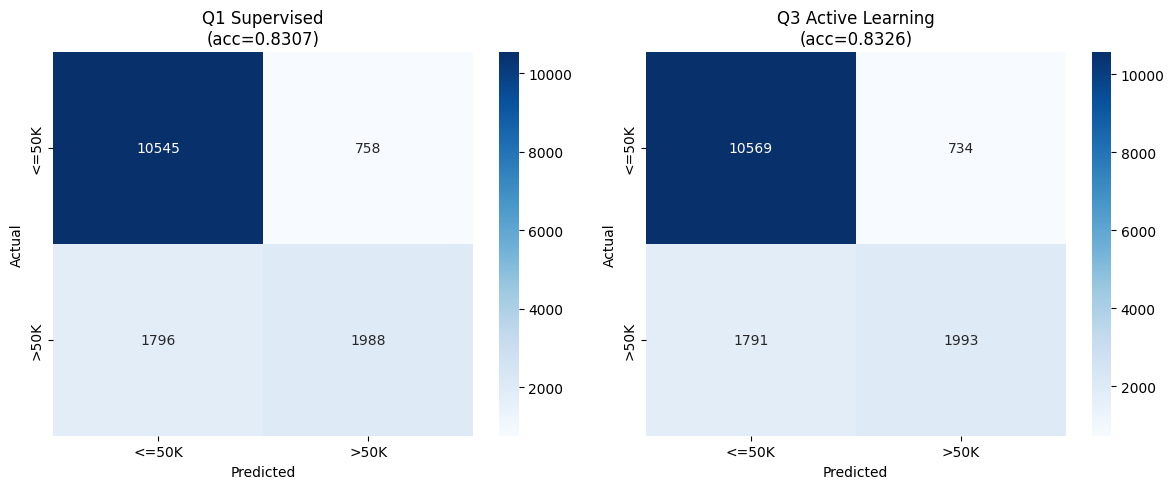

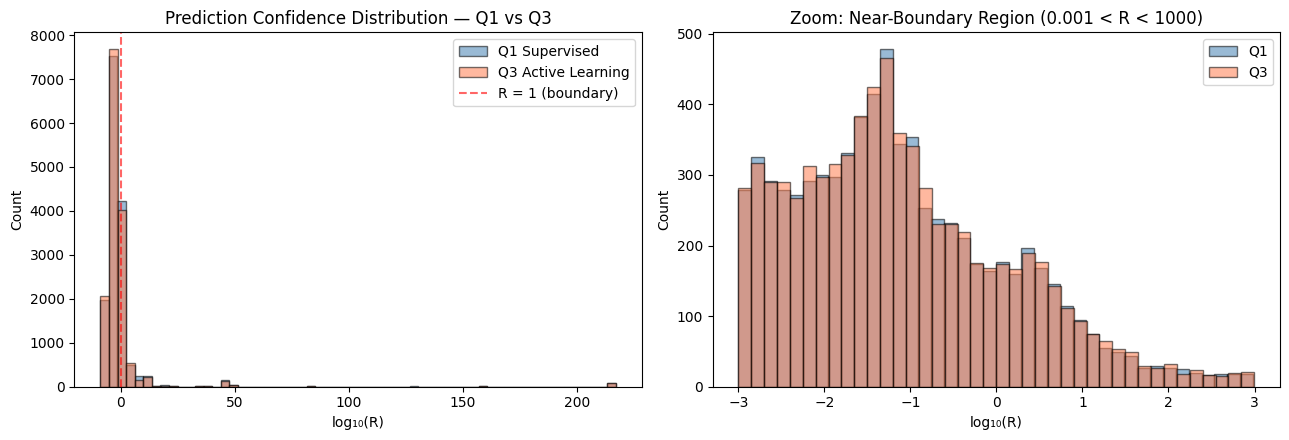

Q1 — Median R: 3.73e-03,  0.5 < R < 2 (near boundary): 685
     R > 1000 (confident >50K): 1286,  R < 0.001 (confident <=50K): 6417
Q3 — Median R: 3.87e-03,  0.5 < R < 2 (near boundary): 688
     R > 1000 (confident >50K): 1230,  R < 0.001 (confident <=50K): 6379

===== Continuous Feature Parameter Changes (Q1 → Q3) =====
       feature class mean_Q1 mean_Q3   Δmean   std_Q1   std_Q3     Δstd
           age <=50K   37.05   37.22  +0.174    13.71    13.88   +0.168
           age  >50K   43.94   44.06  +0.124    10.30    10.42   +0.115
 education-num <=50K    9.63    9.60  -0.026     2.45     2.50   +0.048
 education-num  >50K   11.59   11.62  +0.025     2.36     2.40   +0.031
  capital-gain <=50K  157.67  157.40  -0.263  1017.86  1014.56   -3.306
  capital-gain  >50K 3607.15 3537.48 -69.662 13616.62 13493.63 -122.990
  capital-loss <=50K   55.97   64.98  +9.005   316.02   344.74  +28.724
  capital-loss  >50K  202.36  232.41 +30.051   603.99   646.84  +42.849
hours-per-week <=50K   39.43

In [22]:
# ---- 1. Test-set predictions for both models ----

y_pred_q1, log_post_q1 = predict_mixed_nb(X_test_cont, X_test_cat, mixed_nb_model)
y_pred_q3, log_post_q3 = predict_mixed_nb(X_test_cont, X_test_cat, q3_final_model)

# ---- 2. Side-by-side metrics ----

def model_metrics(y_true, y_pred, label):
    acc  = accuracy_score(y_true, y_pred)
    p0   = precision_score(y_true, y_pred, pos_label=0)
    r0   = recall_score(y_true, y_pred, pos_label=0)
    f0   = f1_score(y_true, y_pred, pos_label=0)
    p1   = precision_score(y_true, y_pred, pos_label=1)
    r1   = recall_score(y_true, y_pred, pos_label=1)
    f1   = f1_score(y_true, y_pred, pos_label=1)
    mf1  = f1_score(y_true, y_pred, average='macro')
    return {'model': label, 'accuracy': acc,
            'prec_<=50K': p0, 'rec_<=50K': r0, 'F1_<=50K': f0,
            'prec_>50K': p1, 'rec_>50K': r1, 'F1_>50K': f1,
            'macro_F1': mf1}

metrics_q1 = model_metrics(y_test, y_pred_q1, 'Q1 Supervised')
metrics_q3 = model_metrics(y_test, y_pred_q3, 'Q3 Active Learning')

comparison_df = pd.DataFrame([metrics_q1, metrics_q3])
print("===== Test-Set Performance Comparison =====")
print(comparison_df.to_string(index=False))

print("\n--- Q1 Supervised ---")
print(classification_report(y_test, y_pred_q1, target_names=['<=50K', '>50K']))

print("--- Q3 Active Learning ---")
print(classification_report(y_test, y_pred_q3, target_names=['<=50K', '>50K']))

# ---- 3. Confusion matrices side by side ----

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes,
                              [y_pred_q1, y_pred_q3],
                              ['Q1 Supervised', 'Q3 Active Learning']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\n(acc={accuracy_score(y_test, y_pred):.4f})')
plt.tight_layout()
plt.show()

# ---- 4. Confidence distribution shift ----

def compute_R(log_posterior):
    """Posterior ratio R = P(>50K|x) / P(<=50K|x); same definition as Q2.3."""
    log_ratio = log_posterior[:, 1] - log_posterior[:, 0]
    return np.exp(np.clip(log_ratio, -500, 500))

R_q1 = compute_R(log_post_q1)
R_q3 = compute_R(log_post_q3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Full distribution
for R_vals, label, color in [(R_q1, 'Q1 Supervised', 'steelblue'),
                              (R_q3, 'Q3 Active Learning', 'coral')]:
    log10_R = np.log10(np.clip(R_vals, 1e-300, None))
    axes[0].hist(log10_R, bins=60, alpha=0.55, color=color, edgecolor='black', label=label)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.6, label='R = 1 (boundary)')
axes[0].set_xlabel('log₁₀(R)')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution — Q1 vs Q3')
axes[0].legend()

# Zoom: low-confidence region
for R_vals, label, color in [(R_q1, 'Q1', 'steelblue'),
                              (R_q3, 'Q3', 'coral')]:
    near = np.log10(np.clip(R_vals, 1e-300, None))
    near = near[(near > -3) & (near < 3)]
    axes[1].hist(near, bins=40, alpha=0.55, color=color, edgecolor='black', label=label)
axes[1].set_xlabel('log₁₀(R)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoom: Near-Boundary Region (0.001 < R < 1000)')
axes[1].legend()

plt.tight_layout()
plt.show()

near_mask_q1 = (R_q1 > 0.5) & (R_q1 < 2)
near_mask_q3 = (R_q3 > 0.5) & (R_q3 < 2)
print(f"Q1 — Median R: {np.median(R_q1):.2e},  0.5 < R < 2 (near boundary): {near_mask_q1.sum()}")
print(f"     R > 1000 (confident >50K): {(R_q1 > 1000).sum()},  R < 0.001 (confident <=50K): {(R_q1 < 0.001).sum()}")
print(f"Q3 — Median R: {np.median(R_q3):.2e},  0.5 < R < 2 (near boundary): {near_mask_q3.sum()}")
print(f"     R > 1000 (confident >50K): {(R_q3 > 1000).sum()},  R < 0.001 (confident <=50K): {(R_q3 < 0.001).sum()}")

# ---- 5. Feature parameter changes ----

gnb_q1 = mixed_nb_model['gnb']
gnb_q3 = q3_final_model['gnb']
cnb_q1 = mixed_nb_model['cnb']
cnb_q3 = q3_final_model['cnb']

# 5a. Continuous features — mean and std changes
print("\n===== Continuous Feature Parameter Changes (Q1 → Q3) =====")
param_rows = []
for j, feat in enumerate(CONTINUOUS_FEATURES):
    for c, c_label in CLASS_LABELS.items():
        mu_q1  = gnb_q1.theta_[c, j]
        mu_q3  = gnb_q3.theta_[c, j]
        std_q1 = np.sqrt(gnb_q1.var_[c, j])
        std_q3 = np.sqrt(gnb_q3.var_[c, j])
        param_rows.append({
            'feature': feat, 'class': c_label,
            'mean_Q1': f'{mu_q1:.2f}', 'mean_Q3': f'{mu_q3:.2f}', 'Δmean': f'{mu_q3-mu_q1:+.3f}',
            'std_Q1': f'{std_q1:.2f}', 'std_Q3': f'{std_q3:.2f}', 'Δstd': f'{std_q3-std_q1:+.3f}',
        })
param_change_df = pd.DataFrame(param_rows)
print(param_change_df.to_string(index=False))

# 5b. Top categorical predictors — compare R ratios for each class
print("\n===== Top Categorical Predictors: Q1 vs Q3 =====")

def top_categorical_ratios(model, top_n=5):
    """Return the top_n most predictive category values per class using P(v|c1)/P(v|c0)."""
    enc = model['encoder']
    cnb_model = model['cnb']
    rows = []
    for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
        log_probs = cnb_model.feature_log_prob_[feat_idx]
        categories = enc.categories_[feat_idx]
        for v_idx, v_name in enumerate(categories):
            if v_idx >= log_probs.shape[1]:
                continue
            log_ratio = log_probs[1, v_idx] - log_probs[0, v_idx]  # log P(v|>50K) / P(v|<=50K)
            rows.append({'feature': feat_name, 'value': v_name, 'log_ratio': log_ratio})
    ratio_df = pd.DataFrame(rows)

    top_high = ratio_df.nlargest(top_n, 'log_ratio').copy()
    top_high['R'] = np.exp(top_high['log_ratio'])
    top_high['favours'] = '>50K'

    top_low = ratio_df.nsmallest(top_n, 'log_ratio').copy()
    top_low['R'] = np.exp(-top_low['log_ratio'])
    top_low['favours'] = '<=50K'

    return pd.concat([top_high, top_low], ignore_index=True)

top_q1 = top_categorical_ratios(mixed_nb_model, top_n=5)
top_q3 = top_categorical_ratios(q3_final_model, top_n=5)

print("\nQ1 Supervised — Top predictors:")
print(top_q1[['feature', 'value', 'favours', 'R']].to_string(index=False))

print("\nQ3 Active Learning — Top predictors:")
print(top_q3[['feature', 'value', 'favours', 'R']].to_string(index=False))

# 5c. Prior probabilities comparison
print("\n===== Prior Probability Changes =====")
print(f"Q1 priors: P(<=50K) = {gnb_q1.class_prior_[0]:.4f}, P(>50K) = {gnb_q1.class_prior_[1]:.4f}")
print(f"Q3 priors: P(<=50K) = {gnb_q3.class_prior_[0]:.4f}, P(>50K) = {gnb_q3.class_prior_[1]:.4f}")